<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/FGF_gasket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Volume balls (BFS):   0%|          | 0/48 [00:00<?, ?it/s]

Return prob (RW):   0%|          | 0/48 [00:00<?, ?it/s]

MSD (RW + BFS dist):   0%|          | 0/48 [00:00<?, ?it/s]

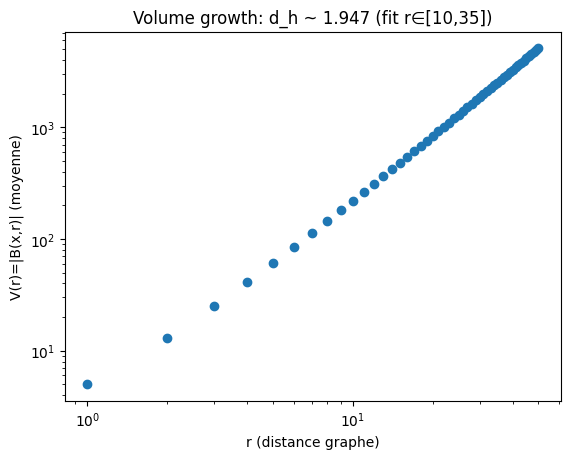

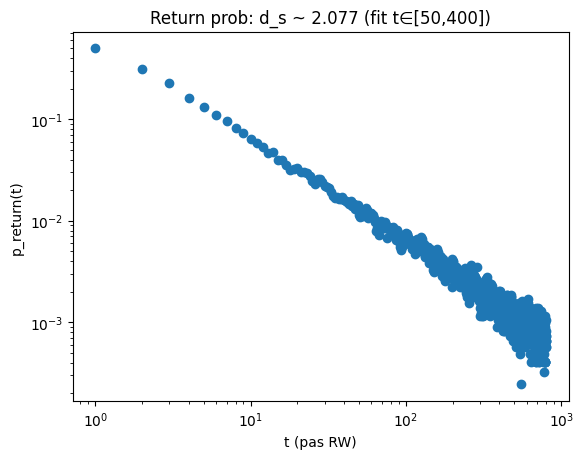

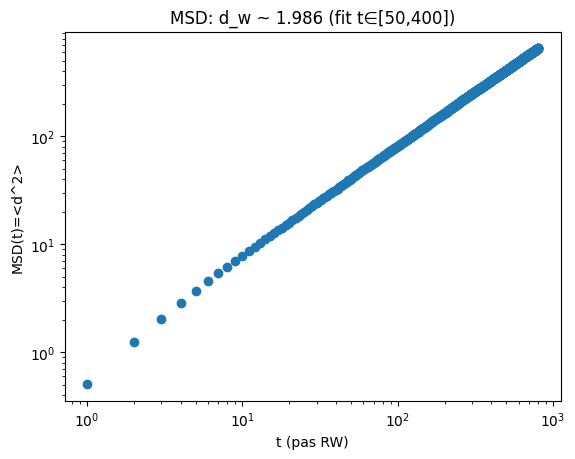

---- Résultats (fenêtres IR) ----
d_h  = 1.946503  (fit r∈[10,35])
d_s  = 2.076618  (fit t∈[50,400], R2=0.9027)
d_w  = 1.985987  (fit t∈[50,400], R2=0.9999)
2 d_h / d_w = 1.960238   (attendu ≈ d_s)
Top 10 fenêtres d_s* (tmin,tmax,slope,R2,npts) :
[(30, 250, -1.016837608504458, 0.944909431477837, 221), (30, 300, -1.0059440855045263, 0.9391208378503366, 271), (30, 275, -1.0099594512238697, 0.939082730302754, 246), (30, 425, -1.0350304322962285, 0.9321025619326139, 396), (30, 400, -1.0327908627232847, 0.9312764024989392, 371), (30, 325, -1.0491738638236443, 0.9312108459071801, 296), (30, 450, -1.0369755694736313, 0.9310749866177566, 421), (30, 475, -1.0406312807980818, 0.9308200461523596, 446), (30, 375, -1.0253846178711026, 0.9305376350109975, 346), (30, 525, -1.0665830652156156, 0.9303527139556542, 496)]

Chosen window for d_s*: (30, 250) R2= 0.944909431477837 npts= 221 => d_s* = 2.033675217008916

Cohérence avec d_s* :
d_s*           = 2.033675217008916
2 d_h / d_w    = 1.9602377064826

In [ ]:
# ============================================================
# Colab notebook (complet) :
# Tests numériques d_h, d_s, d_w sur une tessellation (G_ell)
# conforme à l'étude : adjacence géométrique (4-connexe), pas de diagonales.
#
# Sorties :
#  - d_h via croissance volumique V(r) ~ r^{d_h}
#  - d_s via probabilité de retour p_ret(t) ~ t^{-d_s/2}
#  - d_w via MSD(t) = <d(x0,Xt)^2> ~ t^{2/d_w}
#  - check cohérence : d_s ?≈ 2 d_h / d_w
#
# + Sélection automatique (scan fenêtres log-log, max R^2) :
#  - d_s* via p_ret(t)
#  - d_h* via V(r)
#  - d_w* via MSD(t)
#  - cohérence finale : d_s* vs 2 d_h* / d_w*
# ============================================================

# -------------------------
# Cell 1 — Imports
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x


# -------------------------
# Cell 2 — Graph builders
# -------------------------
def build_adj_from_edges(n_nodes, edges, undirected=True, remove_self_loops=True):
    """edges: iterable (u,v). Retourne adjacency list (list[np.array])."""
    neigh = [[] for _ in range(n_nodes)]
    for u, v in edges:
        if remove_self_loops and u == v:
            continue
        neigh[u].append(v)
        if undirected:
            neigh[v].append(u)

    adj = []
    for u in range(n_nodes):
        if len(neigh[u]) == 0:
            adj.append(np.array([], dtype=np.int32))
        else:
            a = np.array(neigh[u], dtype=np.int32)
            a = np.unique(a)
            adj.append(a)
    return adj


# -------------------------
# Cell 3 — BFS ball volumes (d_h)
# -------------------------
def ball_volume_counts(adj, center, r_max):
    """
    BFS tronqué profondeur r_max.
    Retourne:
      r: 1..r_max
      V(r)=|B(center,r)|
    """
    dist = {center: 0}
    q = deque([center])
    shell = np.zeros(r_max + 1, dtype=np.int64)
    shell[0] = 1

    while q:
        u = q.popleft()
        du = dist[u]
        if du == r_max:
            continue
        for v in adj[u]:
            v = int(v)
            if v not in dist:
                dv = du + 1
                dist[v] = dv
                if dv <= r_max:
                    shell[dv] += 1
                    q.append(v)

    V = np.cumsum(shell)
    r = np.arange(1, r_max + 1)
    return r, V[1:].astype(np.float64)


def estimate_dh_volume_growth(adj, r_max=50, n_centers=48, seed=0, r_fit_min=10, r_fit_max=35):
    rng = np.random.default_rng(seed)
    deg = np.array([len(a) for a in adj], dtype=int)
    valid = np.where(deg > 0)[0]
    if valid.size == 0:
        raise ValueError("Graphe sans arêtes.")
    centers = rng.choice(valid, size=min(n_centers, valid.size), replace=False)

    Vs = []
    for c in tqdm(centers, desc="Volume balls (BFS)"):
        r, V = ball_volume_counts(adj, int(c), r_max)
        Vs.append(V)
    V_mean = np.mean(np.stack(Vs, axis=0), axis=0)

    mask = (r >= r_fit_min) & (r <= r_fit_max) & (V_mean > 0)
    x = np.log(r[mask])
    y = np.log(V_mean[mask])
    A = np.vstack([np.ones_like(x), x]).T
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    a0, dh = coef[0], coef[1]
    det = dict(r_fit_min=r_fit_min, r_fit_max=r_fit_max, intercept=float(a0))
    return r, V_mean, float(dh), det


# -------------------------
# Cell 4 — Random walk + p_return (d_s) + MSD (d_w)
# -------------------------
def random_walk_lazy(adj, start_nodes, T, p_stay=0.5, rng=None):
    """
    Marche aléatoire lazy :
      - avec proba p_stay: rester
      - sinon: saut uniforme vers un voisin
    Retourne traj: (T+1, n_walkers)
    """
    if rng is None:
        rng = np.random.default_rng(0)

    start_nodes = np.asarray(start_nodes, dtype=np.int32)
    n_walkers = start_nodes.size
    traj = np.empty((T + 1, n_walkers), dtype=np.int32)
    traj[0] = start_nodes
    pos = start_nodes.copy()

    deg = np.array([len(a) for a in adj], dtype=np.int32)
    for t in range(1, T + 1):
        stay = rng.random(n_walkers) < p_stay if p_stay > 0 else np.zeros(n_walkers, dtype=bool)
        move_idx = np.where(~stay)[0]
        if move_idx.size > 0:
            for k in move_idx:
                u = int(pos[k])
                d = int(deg[u])
                if d == 0:
                    continue
                j = rng.integers(0, d)
                pos[k] = adj[u][j]
        traj[t] = pos
    return traj


def estimate_ds_return_prob(adj, T=800, n_centers=48, n_walkers_per_center=256, p_stay=0.5, seed=0):
    """
    Estime p_ret(t)=P(X_t=X_0) (moyenne sur centres + marcheurs).
    Retourne:
      t = 1..T
      p_ret(t)
    """
    rng = np.random.default_rng(seed)
    deg = np.array([len(a) for a in adj], dtype=int)
    valid = np.where(deg > 0)[0]
    centers = rng.choice(valid, size=min(n_centers, valid.size), replace=False)

    p_acc = np.zeros(T + 1, dtype=np.float64)

    for c in tqdm(centers, desc="Return prob (RW)"):
        starts = np.full(n_walkers_per_center, int(c), dtype=np.int32)
        traj = random_walk_lazy(adj, starts, T=T, p_stay=p_stay, rng=rng)
        ret = (traj == starts[None, :]).mean(axis=1)  # moyenne marcheurs
        p_acc += ret

    p = p_acc / max(len(centers), 1)
    t = np.arange(1, T + 1)
    return t, p[1:]


def estimate_dw_msd(adj, T=800, n_centers=48, n_walkers_per_center=256, p_stay=0.5, seed=0):
    """
    MSD(t)=<d_graph(x0,Xt)^2> : distances BFS depuis x0 (un BFS par centre).
    Retourne:
      t = 1..T
      msd(t)
    """
    rng = np.random.default_rng(seed)
    n = len(adj)
    deg = np.array([len(a) for a in adj], dtype=int)
    valid = np.where(deg > 0)[0]
    centers = rng.choice(valid, size=min(n_centers, valid.size), replace=False)

    msd_acc = np.zeros(T + 1, dtype=np.float64)

    for c in tqdm(centers, desc="MSD (RW + BFS dist)"):
        c = int(c)

        # BFS distances
        dist = np.full(n, -1, dtype=np.int32)
        dist[c] = 0
        q = deque([c])
        while q:
            u = q.popleft()
            du = dist[u]
            for v in adj[u]:
                v = int(v)
                if dist[v] < 0:
                    dist[v] = du + 1
                    q.append(v)

        starts = np.full(n_walkers_per_center, c, dtype=np.int32)
        traj = random_walk_lazy(adj, starts, T=T, p_stay=p_stay, rng=rng)

        d2 = (dist[traj] ** 2).mean(axis=1)
        msd_acc += d2

    msd = msd_acc / max(len(centers), 1)
    t = np.arange(1, T + 1)
    return t, msd[1:]


# -------------------------
# Cell 5 — Régression log-log + scan fenêtres
# -------------------------
def linreg_loglog(x, y):
    X = np.log(np.asarray(x, dtype=np.float64))
    Y = np.log(np.asarray(y, dtype=np.float64))
    A = np.vstack([np.ones_like(X), X]).T
    coef, *_ = np.linalg.lstsq(A, Y, rcond=None)
    a, b = coef  # Y = a + b X
    Yhat = A @ coef
    ss_res = np.sum((Y - Yhat) ** 2)
    ss_tot = np.sum((Y - Y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(a), float(b), float(r2)


def scan_windows(x, y, mins, maxs, min_pts=40, y_min=1e-18):
    """
    Retourne liste triée de fenêtres candidates:
      (xmin, xmax, slope b, R2, npts)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    rows = []
    for xmin in mins:
        for xmax in maxs:
            if xmax <= xmin:
                continue
            m = (x >= xmin) & (x <= xmax) & (y > y_min)
            if np.sum(m) < min_pts:
                continue
            a, b, r2 = linreg_loglog(x[m], y[m])
            rows.append((int(xmin), int(xmax), float(b), float(r2), int(np.sum(m))))
    rows.sort(key=lambda z: (-(z[3] if np.isfinite(z[3]) else -np.inf), -(z[1] - z[0])))
    return rows


# -------------------------
# Cell 6 — Tessellation 4-connexe + runner IR
# -------------------------
def make_tessellation_grid_4conn(L, periodic=True):
    """
    Tessellation carrée LxL.
    - sommets = cellules
    - arêtes = partage d'un bord (4-voisins)
    periodic=True -> tore (évite effets de bord)
    """
    n = L * L

    def idx(i, j):
        return (i % L) * L + (j % L)

    edges = []
    for i in range(L):
        for j in range(L):
            u = idx(i, j)
            if periodic or (j + 1 < L):
                edges.append((u, idx(i, j + 1)))
            if periodic or (i + 1 < L):
                edges.append((u, idx(i + 1, j)))

    return build_adj_from_edges(n, edges, undirected=True)


def run_demo_IR(adj,
                r_max=50, T=800,
                n_centers=48, n_walkers_per_center=256,
                p_stay=0.5, seed=123,
                r_fit_min=10, r_fit_max=35,
                t_fit_min=50, t_fit_max=400,
                do_plots=True):
    # d_h
    r, Vmean, dh, dh_det = estimate_dh_volume_growth(
        adj, r_max=r_max, n_centers=n_centers, seed=seed,
        r_fit_min=r_fit_min, r_fit_max=r_fit_max
    )

    # p_return (d_s "fenêtre fixée")
    t_ret, p_ret = estimate_ds_return_prob(
        adj, T=T, n_centers=n_centers, n_walkers_per_center=n_walkers_per_center,
        p_stay=p_stay, seed=seed + 1
    )
    m = (t_ret >= t_fit_min) & (t_ret <= t_fit_max) & (p_ret > 0)
    a, b, r2 = linreg_loglog(t_ret[m], p_ret[m])
    ds = -2.0 * b
    ds_det = dict(t_min=t_fit_min, t_max=t_fit_max, slope=float(b), intercept=float(a), r2=float(r2))

    # MSD (d_w)
    t_msd, msd = estimate_dw_msd(
        adj, T=T, n_centers=n_centers, n_walkers_per_center=n_walkers_per_center,
        p_stay=p_stay, seed=seed + 2
    )
    m2 = (t_msd >= t_fit_min) & (t_msd <= t_fit_max) & (msd > 0)
    a2, b2, r2_2 = linreg_loglog(t_msd[m2], msd[m2])
    dw = 2.0 / b2 if b2 > 0 else np.nan
    dw_det = dict(t_min=t_fit_min, t_max=t_fit_max, slope=float(b2), intercept=float(a2), r2=float(r2_2))

    ds_pred = 2.0 * dh / dw if (dw and not np.isnan(dw)) else np.nan

    if do_plots:
        plt.figure()
        plt.loglog(r, Vmean, marker="o", linestyle="none")
        plt.xlabel("r (distance graphe)")
        plt.ylabel("V(r)=|B(x,r)| (moyenne)")
        plt.title(f"Volume growth: d_h ~ {dh:.3f} (fit r∈[{r_fit_min},{r_fit_max}])")
        plt.show()

        plt.figure()
        plt.loglog(t_ret, p_ret, marker="o", linestyle="none")
        plt.xlabel("t (pas RW)")
        plt.ylabel("p_return(t)")
        plt.title(f"Return prob: d_s ~ {ds:.3f} (fit t∈[{t_fit_min},{t_fit_max}])")
        plt.show()

        plt.figure()
        plt.loglog(t_msd, msd, marker="o", linestyle="none")
        plt.xlabel("t (pas RW)")
        plt.ylabel("MSD(t)=<d^2>")
        plt.title(f"MSD: d_w ~ {dw:.3f} (fit t∈[{t_fit_min},{t_fit_max}])")
        plt.show()

        print("---- Résultats (fenêtres IR) ----")
        print(f"d_h  = {dh:.6f}  (fit r∈[{dh_det['r_fit_min']},{dh_det['r_fit_max']}])")
        print(f"d_s  = {ds:.6f}  (fit t∈[{ds_det['t_min']},{ds_det['t_max']}], R2={ds_det['r2']:.4f})")
        print(f"d_w  = {dw:.6f}  (fit t∈[{dw_det['t_min']},{dw_det['t_max']}], R2={dw_det['r2']:.4f})")
        print(f"2 d_h / d_w = {ds_pred:.6f}   (attendu ≈ d_s)")

    return {
        "d_h": float(dh),
        "d_s": float(ds),
        "d_w": float(dw),
        "d_s_pred_2dh_over_dw": float(ds_pred),
        "details": {"dh": dh_det, "ds": ds_det, "dw": dw_det},
        "series": {
            "r": r, "Vmean": Vmean,
            "t_ret": t_ret, "p_ret": p_ret,
            "t_msd": t_msd, "msd": msd
        }
    }


# -------------------------
# Cell 7 — Exécution (sanity check)
# -------------------------
L = 160
periodic = True
adj_demo = make_tessellation_grid_4conn(L=L, periodic=periodic)

res = run_demo_IR(
    adj_demo,
    r_max=50,
    T=800,
    n_centers=48,
    n_walkers_per_center=256,
    p_stay=0.5,      # mettre 0.0 si tu veux non-lazy
    seed=123,
    r_fit_min=10, r_fit_max=35,
    t_fit_min=50, t_fit_max=400,
    do_plots=True
)

# -------------------------
# Cell 8 — Scan automatique de fenêtres pour d_s* (p_return)
# -------------------------
t1 = res["series"]["t_ret"]
p_ret = res["series"]["p_ret"]

tmins = range(30, 201, 10)
tmaxs = range(250, 801, 25)
rows = scan_windows(t1, p_ret, tmins, tmaxs, min_pts=40)

print("Top 10 fenêtres d_s* (tmin,tmax,slope,R2,npts) :")
print(rows[:10])

tmin, tmax, b, r2, npts = rows[0]
ds_best = -2.0 * b

print("\nChosen window for d_s*:", (tmin, tmax), "R2=", r2, "npts=", npts, "=> d_s* =", ds_best)

res["d_s_best"] = float(ds_best)
res["details"]["ds_best"] = {"t_min": int(tmin), "t_max": int(tmax), "slope": float(b), "r2": float(r2), "npts": int(npts)}

print("\nCohérence avec d_s* :")
print("d_s*           =", res["d_s_best"])
print("2 d_h / d_w    =", res["d_s_pred_2dh_over_dw"])


# -------------------------
# Cell 9 — Scan automatique de fenêtres pour d_h* (V(r)) et d_w* (MSD)
# -------------------------
# --- d_h* via V(r)
r = res["series"]["r"]
V = res["series"]["Vmean"]

rmins = range(6, 21, 2)
rmaxs = range(25, 61, 5)
rows_h = scan_windows(r, V, rmins, rmaxs, min_pts=12)

print("\nTop 10 fenêtres d_h* (rmin,rmax,slope,R2,npts) :")
print(rows_h[:10])

rmin, rmax, b_h, r2_h, npts_h = rows_h[0]
dh_best = b_h  # log V ~ a + d_h log r

print("\nChosen window for d_h*:", (rmin, rmax), "R2=", r2_h, "=> d_h* =", dh_best)

res["d_h_best"] = float(dh_best)
res["details"]["dh_best"] = {"r_min": int(rmin), "r_max": int(rmax), "slope": float(b_h), "r2": float(r2_h), "npts": int(npts_h)}

# --- d_w* via MSD(t)
t2 = res["series"]["t_msd"]
msd = res["series"]["msd"]

tmins2 = range(30, 201, 10)
tmaxs2 = range(250, 801, 25)
rows_w = scan_windows(t2, msd, tmins2, tmaxs2, min_pts=40)

print("\nTop 10 fenêtres d_w* (tmin,tmax,slope,R2,npts) :")
print(rows_w[:10])

tmin_w, tmax_w, b_w, r2_w, npts_w = rows_w[0]
dw_best = 2.0 / b_w

print("\nChosen window for d_w*:", (tmin_w, tmax_w), "R2=", r2_w, "=> d_w* =", dw_best)

res["d_w_best"] = float(dw_best)
res["details"]["dw_best"] = {"t_min": int(tmin_w), "t_max": int(tmax_w), "slope": float(b_w), "r2": float(r2_w), "npts": int(npts_w)}

# --- Cohérence finale (versions scannées)
print("\nCohérence scannée :")
print("d_s*                 =", res["d_s_best"])
print("2 d_h* / d_w*        =", 2.0 * res["d_h_best"] / res["d_w_best"])

In [ ]:
# ============================================================
# Cell — Coarse-graining 2×2 (Appendix C.6 style) + rerun + tableau récap
# Prérequis: avoir déjà défini dans le notebook:
#   - make_tessellation_grid_4conn
#   - run_demo_IR
#   - scan_windows
#   - linreg_loglog
# ============================================================

import numpy as np
import pandas as pd

def edge_count_undirected(adj):
    return int(sum(len(a) for a in adj) // 2)

def partition_grid_block(L, block=2):
    """
    Partition d'une grille LxL en blocs block×block (block=2 pour C.6).
    L doit être multiple de block.
    """
    assert L % block == 0
    part = np.empty(L * L, dtype=np.int32)
    Lc = L // block
    for i in range(L):
        for j in range(L):
            bi = i // block
            bj = j // block
            part[i * L + j] = bi * Lc + bj
    return part, Lc

def coarse_grain_by_partition(adj, part):
    """
    Graphe coarse (non pondéré):
      arête entre blocs si une arête fine relie deux blocs.
    """
    N = len(adj)
    K = int(part.max()) + 1
    acc = [set() for _ in range(K)]
    for u in range(N):
        bu = int(part[u])
        for v in adj[u]:
            bv = int(part[int(v)])
            if bv != bu:
                acc[bu].add(bv)
    return [np.array(sorted(s), dtype=np.int32) for s in acc]

def add_scans_to_res(res, r_max_used, T_used):
    """
    Ajoute d_s*, d_h*, d_w* (fenêtres optimales via scan_windows) à un dict res.
    Hypothèse: res["series"] contient r,Vmean,t_ret,p_ret,t_msd,msd.
    """
    # --- d_s* (p_return)
    t = res["series"]["t_ret"]
    p = res["series"]["p_ret"]
    tmins = range(30, min(201, T_used//2), 10)
    tmaxs = range(min(250, T_used), T_used + 1, 25)
    rows = scan_windows(t, p, tmins, tmaxs, min_pts=40)
    if len(rows) > 0:
        tmin, tmax, b, r2, npts = rows[0]
        res["d_s_best"] = float(-2.0 * b)
        res["details"]["ds_best"] = {"t_min": int(tmin), "t_max": int(tmax), "slope": float(b),
                                     "r2": float(r2), "npts": int(npts)}
    else:
        res["d_s_best"] = np.nan
        res["details"]["ds_best"] = None

    # --- d_h* (V(r))
    r = res["series"]["r"]
    V = res["series"]["Vmean"]
    # fenêtres adaptées à r_max_used
    rmin_max = max(6, min(30, r_max_used - 10))
    rmax_min = max(20, min(35, r_max_used - 5))
    rmins = range(4, rmin_max + 1, 2)
    rmaxs = range(rmax_min, r_max_used + 1, 5)
    rows_h = scan_windows(r, V, rmins, rmaxs, min_pts=12)
    if len(rows_h) > 0:
        rmin, rmax, b_h, r2_h, npts_h = rows_h[0]
        res["d_h_best"] = float(b_h)
        res["details"]["dh_best"] = {"r_min": int(rmin), "r_max": int(rmax), "slope": float(b_h),
                                     "r2": float(r2_h), "npts": int(npts_h)}
    else:
        res["d_h_best"] = np.nan
        res["details"]["dh_best"] = None

    # --- d_w* (MSD)
    t2 = res["series"]["t_msd"]
    msd = res["series"]["msd"]
    tmins2 = range(30, min(201, T_used//2), 10)
    tmaxs2 = range(min(250, T_used), T_used + 1, 25)
    rows_w = scan_windows(t2, msd, tmins2, tmaxs2, min_pts=40)
    if len(rows_w) > 0:
        tmin_w, tmax_w, b_w, r2_w, npts_w = rows_w[0]
        res["d_w_best"] = float(2.0 / b_w) if b_w > 0 else np.nan
        res["details"]["dw_best"] = {"t_min": int(tmin_w), "t_max": int(tmax_w), "slope": float(b_w),
                                     "r2": float(r2_w), "npts": int(npts_w)}
    else:
        res["d_w_best"] = np.nan
        res["details"]["dw_best"] = None

    # Cohérence scannée
    if np.isfinite(res.get("d_h_best", np.nan)) and np.isfinite(res.get("d_w_best", np.nan)) and res["d_w_best"] > 0:
        res["coh_scanned_2dh_over_dw"] = float(2.0 * res["d_h_best"] / res["d_w_best"])
    else:
        res["coh_scanned_2dh_over_dw"] = np.nan

    return res

def run_levels_grid_coarse_grain(
    L0=160,
    periodic=True,
    n_levels=1,          # 1 => G_ell puis G_{ell+1} (2×2)
    block=2,
    # paramètres de run_demo_IR (fixes)
    r_max=50,
    T=800,
    n_centers=48,
    n_walkers_per_center=256,
    p_stay=0.5,
    seed=123,
    r_fit_min=10, r_fit_max=35,
    t_fit_min=50, t_fit_max=400,
    do_plots=False
):
    L = L0
    adj = make_tessellation_grid_4conn(L=L, periodic=periodic)

    rows = []
    all_res = []

    for level in range(n_levels + 1):
        # adapter r_max au niveau (graphe plus petit)
        r_max_lvl = min(r_max, max(15, int(0.35 * L))) if periodic else min(r_max, 30)

        res = run_demo_IR(
            adj,
            r_max=r_max_lvl,
            T=T,
            n_centers=n_centers,
            n_walkers_per_center=n_walkers_per_center,
            p_stay=p_stay,
            seed=seed + 1000 * level,
            r_fit_min=min(r_fit_min, r_max_lvl - 5),
            r_fit_max=min(r_fit_max, r_max_lvl),
            t_fit_min=t_fit_min,
            t_fit_max=t_fit_max,
            do_plots=do_plots
        )
        res = add_scans_to_res(res, r_max_used=r_max_lvl, T_used=T)
        all_res.append(res)

        N = len(adj)
        E = edge_count_undirected(adj)

        rows.append({
            "level": level,
            "L_grid": L,
            "N_nodes": N,
            "E_edges": E,
            "d_h_fixed": res["d_h"],
            "d_s_fixed": res["d_s"],
            "d_w_fixed": res["d_w"],
            "2dh/dw_fixed": res["d_s_pred_2dh_over_dw"],
            "d_h*": res.get("d_h_best", np.nan),
            "d_s*": res.get("d_s_best", np.nan),
            "d_w*": res.get("d_w_best", np.nan),
            "2dh*/dw*": res.get("coh_scanned_2dh_over_dw", np.nan),
            "ds*_R2": (res["details"]["ds_best"]["r2"] if res["details"].get("ds_best") else np.nan),
            "dh*_R2": (res["details"]["dh_best"]["r2"] if res["details"].get("dh_best") else np.nan),
            "dw*_R2": (res["details"]["dw_best"]["r2"] if res["details"].get("dw_best") else np.nan),
        })

        # coarse-grain pour le niveau suivant
        if level < n_levels:
            part, Lc = partition_grid_block(L, block=block)
            adj = coarse_grain_by_partition(adj, part)
            L = Lc

    df = pd.DataFrame(rows)
    display(df)
    return all_res, df


# =========================
# Exemple d’appel (C.6 style):
# - niveau 0: grille L0xL0
# - niveau 1: coarse-graining 2×2
# =========================
all_res, df = run_levels_grid_coarse_grain(
    L0=160,
    periodic=True,
    n_levels=2,          # 0 -> 1 -> 2 (deux coarse-grainings successifs)
    block=2,
    r_max=50,
    T=800,
    n_centers=48,
    n_walkers_per_center=256,
    p_stay=0.5,          # mettre 0.0 pour non-lazy
    seed=123,
    do_plots=False
)

Volume balls (BFS):   0%|          | 0/48 [00:00<?, ?it/s]

Return prob (RW):   0%|          | 0/48 [00:00<?, ?it/s]

MSD (RW + BFS dist):   0%|          | 0/48 [00:00<?, ?it/s]

Volume balls (BFS):   0%|          | 0/48 [00:00<?, ?it/s]

Return prob (RW):   0%|          | 0/48 [00:00<?, ?it/s]

MSD (RW + BFS dist):   0%|          | 0/48 [00:00<?, ?it/s]

Volume balls (BFS):   0%|          | 0/48 [00:00<?, ?it/s]

Return prob (RW):   0%|          | 0/48 [00:00<?, ?it/s]

MSD (RW + BFS dist):   0%|          | 0/48 [00:00<?, ?it/s]

,level,L_grid,N_nodes,E_edges,d_h_fixed,d_s_fixed,d_w_fixed,2dh/dw_fixed,d_h*,d_s*,d_w*,2dh*/dw*,ds*_R2,dh*_R2,dw*_R2
0,0,160,25600,51200,1.946503,2.076618,1.985987,1.960238,1.970095,2.033675,1.994853,1.975177,0.944909,0.999999,0.999957
1,1,80,6400,12800,1.940045,1.847839,1.992109,1.947730,1.952656,1.890134,1.987478,1.964960,0.939062,0.999996,0.999955
2,2,40,1600,3200,1.918191,2.028145,2.133468,1.798191,NaN,2.041856,2.093466,NaN,0.940430,NaN,0.999900
